
# SOH CNN+GRU Training + One‑Click Plot Notebook



In [1]:
!pip install tslearn

  Using cached tslearn-0.8.1-py3-none-any.whl.metadata (16 kB)
  Using cached numba-0.65.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
  Using cached llvmlite-0.47.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.0 kB)
Using cached tslearn-0.8.1-py3-none-any.whl (387 kB)
Using cached numba-0.65.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts

In [2]:
# =========================
# CONFIG — KAGGLE VERSION
# =========================

CSV_PATH = "/kaggle/input/datasets/x3n0nn/full-battery-soh-cycle-features/full_battery_with_soh_clean_cycle_elapsed_with_features.csv"

TARGET_COL = "soh_clean"
FALLBACK_TARGET = "soh"

WINDOW_CYCLES = 256
PRED_CYCLES = 128
STRIDE = 128

TRAIN_CELLS = ["CS2_33","CS2_34","CS2_35","CS2_38","CX2_33","CX2_34","CX2_35","CX2_38"]
DEV_CELLS   = ["CS2_36","CX2_36"]
TEST_CELLS  = ["CS2_37","CX2_37"]

WAVE_COLS = [
    "current(a)",
    "voltage(v)",
    "dv/dt(v/s)",
    "internal_resistance(ohm)",
    "cycle_elapsed_time_sec",
]

AUX_COLS = [
    "internal_resistance(ohm)",
    "global_cycle",
    "discharge_time",
    "discharge_energy_cycle",
    "avg_voltage_discharge"
]

# models/artifacts — write to working directory
MODEL_PATH = "/kaggle/working/torch_gru_soh_model_best.h5"
ARTIFACT_PATH = "/kaggle/working/torch_gru_soh_artifacts.pkl"
SLIM_ARTIFACT_PATH = "/kaggle/working/torch_gru_soh_slim_artifacts.pkl"

In [3]:
# =========================
# IMPORTS
# =========================

import os, pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [4]:

# =========================
# LOAD CSV
# =========================

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(CSV_PATH)

df = pd.read_csv(CSV_PATH)

if TARGET_COL not in df.columns:
    TARGET_COL = FALLBACK_TARGET

print("Using target:", TARGET_COL)
print("Rows:", len(df))


Using target: soh_clean
Rows: 5705092


In [5]:
# =========================
# BUILD PER-CYCLE DATA
# =========================

df = df.sort_values(["cell_id","global_cycle","cycle_elapsed_time_sec"])

cycle_data = {}

for (cell, cyc), g in df.groupby(["cell_id","global_cycle"]):
    wave = g[WAVE_COLS].values.astype(np.float32)

    aux = {
        "soh": float(g[TARGET_COL].iloc[0])
    }

    for col in AUX_COLS:
        aux[col] = float(g[col].mean())

    cycle_data.setdefault(cell, []).append((cyc, wave, aux))

print("Cells:", len(cycle_data))

Cells: 13


In [6]:
# =========================
# FIT SCALER ON TRAIN CELLS
# =========================

train_rows = []
for c in TRAIN_CELLS:
    for _, w, _ in cycle_data[c]:
        train_rows.append(w)

train_stack = np.vstack(train_rows)

scaler = StandardScaler()
scaler.fit(train_stack)

for c in cycle_data:
    new = []
    for cyc, w, a in cycle_data[c]:
        w = scaler.transform(w)
        new.append((cyc, w, a))
    cycle_data[c] = new

In [7]:
# =========================
# PAD CYCLES
# =========================

max_len = max(len(w) for c in cycle_data for _, w, _ in cycle_data[c])

def pad(w):
    if len(w) == max_len:
        return w
    pad_rows = max_len - len(w)
    return np.vstack([w, np.zeros((pad_rows, w.shape[1]))])

for c in cycle_data:
    cycle_data[c] = [(cyc, pad(w), a) for cyc, w, a in cycle_data[c]]

print("Max len:", max_len)

Max len: 2998


In [8]:
# =========================
# SAMPLE BUILDER
# =========================

def build_samples(cell_list):
    Xw, Xa, Y = [], [], []

    for cell in cell_list:
        cycles = cycle_data[cell]

        for i in range(0, len(cycles)-WINDOW_CYCLES-PRED_CYCLES, STRIDE):
            win = cycles[i:i+WINDOW_CYCLES]
            fut = cycles[i+WINDOW_CYCLES:i+WINDOW_CYCLES+PRED_CYCLES]

            waves = np.stack([w for _, w, _ in win])

            aux = np.array([
                [a["soh"]] + [a[col] for col in AUX_COLS]
                for _,_,a in win
            ])

            y = np.array([a["soh"] for _,_,a in fut])

            Xw.append(waves)
            Xa.append(aux)
            Y.append(y)

    return np.array(Xw), np.array(Xa), np.array(Y)

Xw_tr, Xa_tr, y_tr = build_samples(TRAIN_CELLS)
Xw_dev, Xa_dev, y_dev = build_samples(DEV_CELLS)

print("Train samples:", len(Xw_tr))

Train samples: 66


In [9]:
# =========================
# AUX FEATURE SCALING
# =========================

aux_scaler = StandardScaler()

aux_flat = Xa_tr.reshape(-1, Xa_tr.shape[-1])
aux_flat = np.nan_to_num(aux_flat)

aux_scaler.fit(aux_flat)

def scale_aux(Xa):
    shp = Xa.shape
    Xa2 = Xa.reshape(-1, shp[-1])
    Xa2 = np.nan_to_num(Xa2)
    Xa2 = aux_scaler.transform(Xa2)
    Xa2 = np.clip(Xa2, -6, 6)
    return Xa2.reshape(shp)

Xa_tr  = scale_aux(Xa_tr)
Xa_dev = scale_aux(Xa_dev)

In [13]:
import torch
import torch.nn as nn

WAVE_CH = len(WAVE_COLS)
AUX_DIM = 1 + len(AUX_COLS)

CNN_OUT  = 512
AUX_OUT  = 16
GRU_IN   = CNN_OUT + AUX_OUT   # still same input size
LSTM_HID = 256


class CNNEncoder(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 32, 4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, 4),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),
        )

    def forward(self, x):
        return self.net(x).flatten(1)   # (B*T, 256)


class SOHModel(nn.Module):
    def __init__(self, wave_ch, aux_dim):
        super().__init__()
        self.enc = CNNEncoder(wave_ch)

        self.aux_enc = nn.Sequential(
            nn.Linear(aux_dim, AUX_OUT),
            nn.ReLU(),
            nn.Linear(AUX_OUT, AUX_OUT),
        )

        # 🔁 GRU → LSTM
        self.lstm = nn.LSTM(
            input_size=GRU_IN,
            hidden_size=LSTM_HID,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
        )

        self.attn = nn.Linear(LSTM_HID, 1)

        self.fc = nn.Sequential(
            nn.Linear(LSTM_HID, PRED_CYCLES),
        )

    def forward(self, wave, aux):
        B, T, L, C = wave.shape

        wave = wave.permute(0, 1, 3, 2).reshape(B * T, C, L)
        feat = self.enc(wave).reshape(B, T, -1)

        if aux.dim() == 2:
            aux = aux.view(B, T, -1)

        aux_feat = self.aux_enc(aux)

        x = torch.cat([feat, aux_feat], dim=-1)   # (B, T, 272)

        # 🔁 LSTM returns (out, (h, c))
        out, (h_n, c_n) = self.lstm(x)            # (B, T, 128)

        # attention pooling
        scores = torch.softmax(self.attn(out), dim=1)
        context = (out * scores).sum(dim=1)       # (B, 128)

        return self.fc(context)

# =========================
# INITIALIZATION
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_model = SOHModel(WAVE_CH, AUX_DIM)

if torch.cuda.device_count() > 1:
    print(f"Found {torch.cuda.device_count()} GPUs — activating DataParallel.")
    model = nn.DataParallel(base_model)
else:
    model = base_model

model.to(device)
print(f"Model ready on {device}")
print(model)

Found 2 GPUs — activating DataParallel.
Model ready on cuda
DataParallel(
  (module): SOHModel(
    (enc): CNNEncoder(
      (net): Sequential(
        (0): Conv1d(5, 32, kernel_size=(4,), stride=(1,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv1d(32, 64, kernel_size=(4,), stride=(1,))
        (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): AdaptiveAvgPool1d(output_size=8)
      )
    )
    (aux_enc): Sequential(
      (0): Linear(in_features=6, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
    )
    (lstm): LSTM(528, 256, num_layers=2, batch_first=True, dropout=0.2)
    (attn): Linear(in_features=256, out_features=1, bias=True)
    (fc): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
    )
  )
)


In [14]:
# =========================
# SAFETY CLEAN BEFORE TRAIN
# =========================

print("NaN check:",
      np.isnan(Xw_tr).any(),
      np.isnan(Xa_tr).any(),
      np.isnan(y_tr).any())

Xw_tr = np.nan_to_num(Xw_tr)
Xa_tr = np.nan_to_num(Xa_tr)
y_tr  = np.nan_to_num(y_tr)

Xw_dev = np.nan_to_num(Xw_dev)
Xa_dev = np.nan_to_num(Xa_dev)
y_dev  = np.nan_to_num(y_dev)

y_tr  = np.clip(y_tr, 0, 1.2)
y_dev = np.clip(y_dev, 0, 1.2)

NaN check: False False False


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tslearn.metrics import SoftDTWLossPyTorch
import warnings

# Suppress Deprecation/Future Warnings to keep the console clean
warnings.filterwarnings("ignore", category=FutureWarning)

# =========================
# TORCH DATASET
# =========================
class DS(Dataset):
    def __init__(self, Xw, Xa, y):
        self.Xw = torch.tensor(Xw, dtype=torch.float32)
        self.Xa = torch.tensor(Xa, dtype=torch.float32)
        self.y  = torch.tensor(y,  dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.Xw[i], self.Xa[i], self.y[i]

# persistent_workers=True prevents the "Unable to join threads" spam in Phase 2
train_loader     = DataLoader(DS(Xw_tr, Xa_tr, y_tr),   batch_size=32, shuffle=True,  
                               num_workers=4, pin_memory=True, persistent_workers=True)
dev_loader       = DataLoader(DS(Xw_dev, Xa_dev, y_dev), batch_size=32, shuffle=False, 
                               num_workers=4, pin_memory=True, persistent_workers=True)
dtw_train_loader = DataLoader(DS(Xw_tr, Xa_tr, y_tr),   batch_size=16, shuffle=True,  
                               num_workers=4, pin_memory=True, persistent_workers=True)


# =========================
# LOSS 1: COSINE HYBRID
# =========================
class SOHHybridLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.mse   = nn.MSELoss()

    def forward(self, y_pred, y_true):
        mse_loss = self.mse(y_pred, y_true)
        cos_loss = torch.mean(1 - F.cosine_similarity(y_pred, y_true, dim=1))
        return self.alpha * mse_loss + self.beta * cos_loss


# =========================
# LOSS 2: SOFT-DTW HYBRID
# =========================
class DTWHybridLoss(nn.Module):
    def __init__(self, gamma=0.05, alpha=0.5):
        super().__init__()
        self.sdtw  = SoftDTWLossPyTorch(gamma=gamma)
        self.mse   = nn.MSELoss()
        self.alpha = alpha

    def forward(self, y_pred, y_true):
        mse_loss = self.mse(y_pred, y_true)
        # Soft-DTW expects (batch, ts_len, dims)
        dtw_loss = self.sdtw(y_pred.unsqueeze(-1), y_true.unsqueeze(-1)).mean()
        return self.alpha * mse_loss + (1 - self.alpha) * dtw_loss


# =========================
# TRAINING PHASE RUNNER
# =========================
def run_training_phase(phase_name, epochs, active_loss_fn, model, loader, dev_loader, device, opt, scheduler):
    print(f"\n{'='*40}\nSTARTING {phase_name} ({epochs} epochs)\n{'='*40}")

    # Use modern torch.amp API
    scaler = torch.amp.GradScaler('cuda') 
    best_loss    = 1e18
    best_weights = None

    for ep in range(epochs):
        model.train()
        tl = 0
        for w, a, y in loader:
            w, a, y = w.to(device), a.to(device), y.to(device)
            opt.zero_grad()
            
            # Autocast updated to torch.amp
            with torch.amp.autocast('cuda'):
                loss = active_loss_fn(model(w, a), y)
            
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()
            tl += loss.item()

        model.eval()
        vl = 0
        with torch.no_grad():
            for w, a, y in dev_loader:
                w, a, y = w.to(device), a.to(device), y.to(device)
                with torch.amp.autocast('cuda'):
                    vl += active_loss_fn(model(w, a), y).item()
        vl /= len(dev_loader)

        print(f"Ep {ep:02d} | Train: {tl/len(loader):.4f} | Val: {vl:.5f} | LR: {opt.param_groups[0]['lr']:.6f}")

        if vl < best_loss:
            best_loss    = vl
            best_weights = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(best_weights, MODEL_PATH)
            print(f"  -> Saved best {phase_name} model!")

        scheduler.step(vl)

    # Restore best weights for this phase
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(best_weights)
    else:
        model.load_state_dict(best_weights)

    return model


# =========================
# EXECUTE TRAINING PIPELINE
# =========================
loss_cosine = SOHHybridLoss(alpha=0.5, beta=0.5).to(device)
loss_dtw    = DTWHybridLoss(gamma=0.1, alpha=0.5).to(device)

opt       = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.7, patience=15)

# Phase 1: Smooth global degradation
model = run_training_phase("PHASE 1: COSINE FOUNDATION", 120, loss_cosine,
                           model, train_loader, dev_loader, device, opt, scheduler)

# Phase 2: Shape alignment for "cliff" drops
model = run_training_phase("PHASE 2: DTW ALIGNMENT", 80, loss_dtw,
                           model, dtw_train_loader, dev_loader, device, opt, scheduler)

model = run_training_phase("PHASE 1: COSINE FOUNDATION", 60, loss_cosine,
                           model, train_loader, dev_loader, device, opt, scheduler)

print("\nTraining complete. Best model saved.")


STARTING PHASE 1: COSINE FOUNDATION (120 epochs)
Ep 00 | Train: 0.6622 | Val: 0.65998 | LR: 0.000300
  -> Saved best PHASE 1: COSINE FOUNDATION model!
Ep 01 | Train: 0.4161 | Val: 0.51597 | LR: 0.000300
  -> Saved best PHASE 1: COSINE FOUNDATION model!
Ep 02 | Train: 0.2823 | Val: 0.34602 | LR: 0.000300
  -> Saved best PHASE 1: COSINE FOUNDATION model!
Ep 03 | Train: 0.1811 | Val: 0.21688 | LR: 0.000300
  -> Saved best PHASE 1: COSINE FOUNDATION model!
Ep 04 | Train: 0.0815 | Val: 0.09799 | LR: 0.000300
  -> Saved best PHASE 1: COSINE FOUNDATION model!
Ep 05 | Train: 0.0333 | Val: 0.01904 | LR: 0.000300
  -> Saved best PHASE 1: COSINE FOUNDATION model!
Ep 06 | Train: 0.0169 | Val: 0.01922 | LR: 0.000300
Ep 07 | Train: 0.0405 | Val: 0.02380 | LR: 0.000300
Ep 08 | Train: 0.0278 | Val: 0.01982 | LR: 0.000300
Ep 09 | Train: 0.0227 | Val: 0.01692 | LR: 0.000300
  -> Saved best PHASE 1: COSINE FOUNDATION model!
Ep 10 | Train: 0.0234 | Val: 0.01509 | LR: 0.000300
  -> Saved best PHASE 1: COS

In [16]:
# =========================
# SAVE ARTIFACTS
# =========================

artifact = {
    "cycle_data": cycle_data,
    "max_len": max_len,
    "WINDOW_CYCLES": WINDOW_CYCLES,
    "PRED_CYCLES": PRED_CYCLES,
    "STRIDE": STRIDE,
    "aux_scaler": aux_scaler,
    "wave_scaler": scaler
}

with open(ARTIFACT_PATH,"wb") as f:
    pickle.dump(artifact,f)

# =========================
# SLIM SAVE ARTIFACTS (Fix for 2.2GB Bloat)
# =========================

slim_artifact = {
    "max_len": max_len,
    "WINDOW_CYCLES": WINDOW_CYCLES,
    "PRED_CYCLES": PRED_CYCLES,
    "STRIDE": STRIDE,
    "wave_scaler": scaler,         # Waveform scaler (StandardScaler)
    "aux_scaler": aux_scaler  # Auxiliary scaler (StandardScaler)
}

with open(SLIM_ARTIFACT_PATH, "wb") as f:
    pickle.dump(slim_artifact, f)

print("Size reduced: cycle_data removed.")

print("Artifacts saved")

Size reduced: cycle_data removed.
Artifacts saved


In [17]:
# =========================
# LOAD FOR PLOTTING ONLY
# =========================

import torch
import pickle

with open(ARTIFACT_PATH,"rb") as f:
    A = pickle.load(f)

cycle_data = A["cycle_data"]
WINDOW_CYCLES = A["WINDOW_CYCLES"]
PRED_CYCLES = A["PRED_CYCLES"]
STRIDE = A["STRIDE"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from collections import OrderedDict

# 1. Create your raw model
AUX_DIM = 1 + len(AUX_COLS)
model = SOHModel(len(WAVE_COLS), AUX_DIM)

# 2. Load the saved weights into memory (mapping to your current device)
state_dict = torch.load(MODEL_PATH, map_location=device)

# 3. Scrub the "module." prefix off the saved dictionary keys
cleaned_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k # Chops off "module."
    cleaned_state_dict[name] = v

# 4. Load the clean weights and move the model to the GPU!
model.load_state_dict(cleaned_state_dict)
model = model.to(device) # 🌟 Prevents the CPU/GPU mismatch error you just had!
model.eval()

print("✅ Model weights loaded and ready on GPU!")

print("Model loaded")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

✅ Model weights loaded and ready on GPU!
Model loaded


SOHModel(
  (enc): CNNEncoder(
    (net): Sequential(
      (0): Conv1d(5, 32, kernel_size=(4,), stride=(1,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv1d(32, 64, kernel_size=(4,), stride=(1,))
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): AdaptiveAvgPool1d(output_size=8)
    )
  )
  (aux_enc): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
  )
  (lstm): LSTM(528, 256, num_layers=2, batch_first=True, dropout=0.2)
  (attn): Linear(in_features=256, out_features=1, bias=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [18]:
# =========================
# SINGLE CELL BUILDER
# =========================

def build_cell(cell):

    cycles = cycle_data[cell]
    Xw, Xa, Y = [], [], []

    for i in range(0, len(cycles)-WINDOW_CYCLES-PRED_CYCLES, STRIDE):

        win = cycles[i:i+WINDOW_CYCLES]
        fut = cycles[i+WINDOW_CYCLES:i+WINDOW_CYCLES+PRED_CYCLES]

        waves = np.stack([w for _, w, _ in win])

        # ✅ SAME AS TRAINING
        aux = np.array([
            [a["soh"]] + [a[col] for col in AUX_COLS]
            for _,_,a in win
        ])

        y = np.array([a["soh"] for _,_,a in fut])

        Xw.append(waves)
        Xa.append(aux)
        Y.append(y)

    return np.array(Xw), np.array(Xa), np.array(Y)

In [19]:
def torch_predict(model, Xw, Xa, batch_size=64):

    device = next(model.parameters()).device
    preds = []

    model.eval()
    with torch.no_grad():

        for i in range(0, len(Xw), batch_size):

            w = torch.tensor(Xw[i:i+batch_size],
                             dtype=torch.float32).to(device)

            a = torch.tensor(Xa[i:i+batch_size],
                             dtype=torch.float32).to(device)

            p = model(w, a).detach().cpu().numpy()
            preds.append(p)

    return np.vstack(preds)

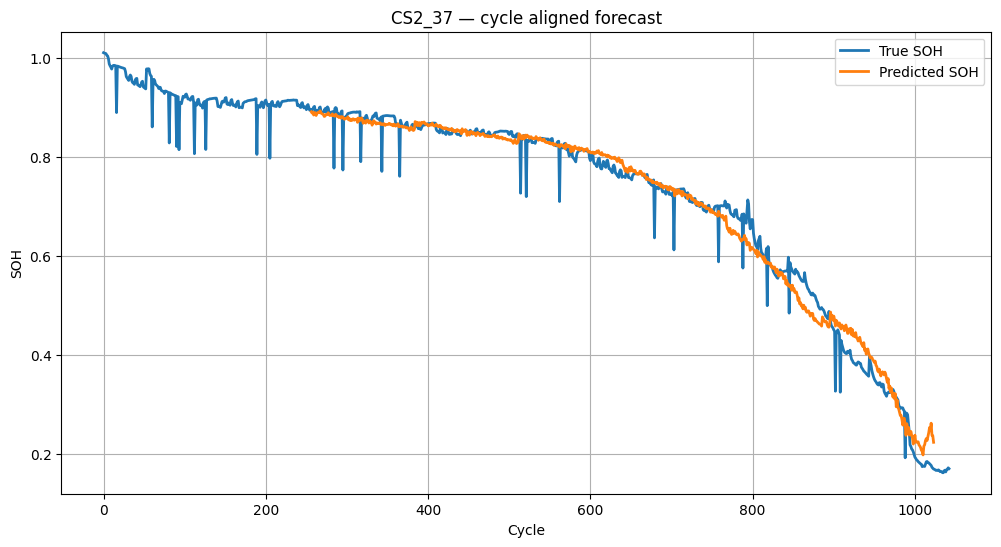

In [23]:
# =========================
# FULL CYCLE PLOT (ALIGNED)
# =========================

PLOT_CELL = "CS2_37"

cycles = cycle_data[PLOT_CELL]

# true SOH per cycle
true_soh = [a["soh"] for _,_,a in cycles]

# build windows
Xw, Xa, y_true = build_cell(PLOT_CELL)

Xa = scale_aux(Xa)

# ---- TORCH PREDICT ----
y_pred = torch_predict(model, Xw, Xa)

WINDOW = WINDOW_CYCLES
PRED   = PRED_CYCLES
STRIDE = STRIDE

pred_sum = [0.0]*len(cycles)
pred_cnt = [0.0]*len(cycles)

sample_i = 0

for start in range(0, len(cycles)-WINDOW-PRED, STRIDE):

    for h in range(PRED):

        cyc_idx = start + WINDOW + h

        if cyc_idx < len(cycles):

            # distance-based weight
            w = 1.0 / np.sqrt(h + 1)

            pred_sum[cyc_idx] += w * y_pred[sample_i, h]
            pred_cnt[cyc_idx] += w

    sample_i += 1


pred_curve = [
    pred_sum[i]/pred_cnt[i] if pred_cnt[i] > 0 else None
    for i in range(len(cycles))
]


# =========================
# PLOT TRUE VS PREDICTED SOH
# =========================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

plt.plot(true_soh, label="True SOH", linewidth=2)

pred_plot = [
    np.nan if v is None else v
    for v in pred_curve
]

plt.plot(pred_plot, label="Predicted SOH", linewidth=2)

plt.title(PLOT_CELL + " — cycle aligned forecast")
plt.xlabel("Cycle")
plt.ylabel("SOH")

plt.legend()
plt.grid(True)
plt.show()

In [24]:
# =========================
# METRICS BLOCK
# =========================

import numpy as np
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    max_error
)

true_arr = np.array(true_soh, dtype=float)

pred_arr = np.array([
    np.nan if v is None else v
    for v in pred_curve
], dtype=float)

mask = ~np.isnan(pred_arr)

y_true = true_arr[mask]
y_pred = pred_arr[mask]

print("Samples used for evaluation:", len(y_true))

r2   = r2_score(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
mxer = max_error(y_true, y_pred)

corr = np.corrcoef(y_true, y_pred)[0,1]

print("\n===== MODEL PERFORMANCE =====")
print(f"R2 Score        : {r2:.4f}")
print(f"MAE             : {mae:.5f}")
print(f"RMSE            : {rmse:.5f}")
print(f"MAPE (%)        : {mape:.3f}")
print(f"Max Error       : {mxer:.5f}")
print(f"Correlation     : {corr:.4f}")

Samples used for evaluation: 768

===== MODEL PERFORMANCE =====
R2 Score        : 0.9806
MAE             : 0.01870
RMSE            : 0.02784
MAPE (%)        : 3.967
Max Error       : 0.13172
Correlation     : 0.9905


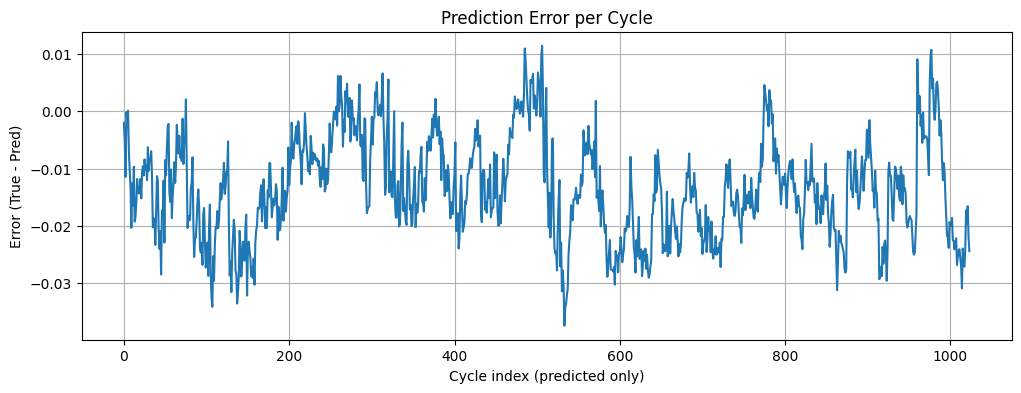

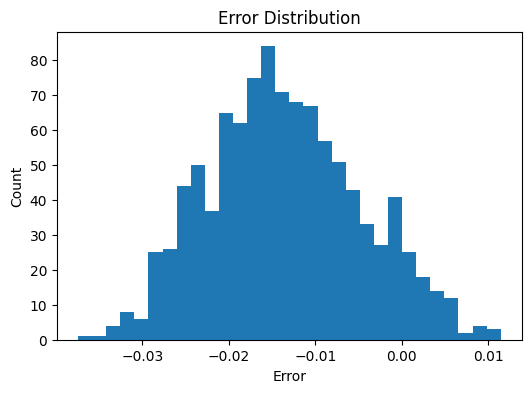

In [22]:
# =========================
# ERROR PLOTS
# =========================

errors = y_true - y_pred

plt.figure(figsize=(12,4))
plt.plot(errors)
plt.title("Prediction Error per Cycle")
plt.xlabel("Cycle index (predicted only)")
plt.ylabel("Error (True - Pred)")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()